In [1]:
import package.global_vars

In [12]:
import os
import re
import math
import json
import random
from package.items import Item
from Tester import Tester
import pickle

In [9]:
from huggingface_hub import login
from openai import OpenAI
from anthropic import Anthropic

In [10]:
openai = OpenAI()
claude = Anthropic()
hf_token = os.environ['HF_TOKEN']
login(hf_token, add_to_git_credential=True)

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


In [23]:
with open('train_lite.pkl', 'rb') as file:
    train = pickle.load(file)

with open('test_lite.pkl', 'rb') as file:
    test = pickle.load(file)

In [25]:
def messages_for(item):
    system_message = "You estimate prices of items. Reply only with the price, no explanation"
    user_prompt = item.test_prompt().replace(" to the nearest dollar","").replace("\n\nPrice is $","")
    return [
        {"role": "system", "content": system_message},
        {"role": "user", "content": user_prompt},
        {"role": "assistant", "content": "Price is $"}
    ]

def get_price(s):
    s = s.replace('$','').replace(',','')
    match = re.search(r"[-+]?\d*\.\d+|\d+", s)
    return float(match.group()) if match else 0

In [28]:
def gpt_4o_pricer(item):
    response = openai.chat.completions.create(
        model=package.global_vars.model_openai_4omini,
        seed=42,
        max_tokens=5,
        messages=messages_for(item)
    )
    reply = response.choices[0].message.content
    return get_price(reply)

1: Guess: $49.99 Truth: $65.99 Error: $16.00 SLE: 0.07 Item: Setpower Insulated Protective Cover for ...
2: Guess: $10.99 Truth: $9.68 Error: $1.31 SLE: 0.01 Item: TUAIC Refrigerator Door Light Switch 2 F...
3: Guess: $129.99 Truth: $155.98 Error: $25.99 SLE: 0.03 Item: Kegco Secondary Regulator, 3 Product, Ch...
4: Guess: $0.00 Truth: $5.59 Error: $5.59 SLE: 3.56 Item: MHY62044106 Refrigerator Door Spring 2Pc...
5: Guess: $30.00 Truth: $98.40 Error: $68.40 SLE: 1.36 Item: Ice-O-Matic 9131111-01 Float Valve
6: Guess: $35.99 Truth: $54.99 Error: $19.00 SLE: 0.17 Item: Wireless Temperature & Humidity Bluetoot...
7: Guess: $10.99 Truth: $5.71 Error: $5.28 SLE: 0.34 Item: 3Inch Thermometer Hygrometer for Indoor ...
8: Guess: $12.99 Truth: $9.53 Error: $3.46 SLE: 0.08 Item: GE WH1X2754 GE Timer Knob Assembly,white
9: Guess: $14.99 Truth: $11.24 Error: $3.75 SLE: 0.07 Item: newlifeapp 33001003 Dryer Lint Screen Fi...
10: Guess: $29.99 Truth: $12.88 Error: $17.11 SLE: 0.65 Item: Away NV350 NV

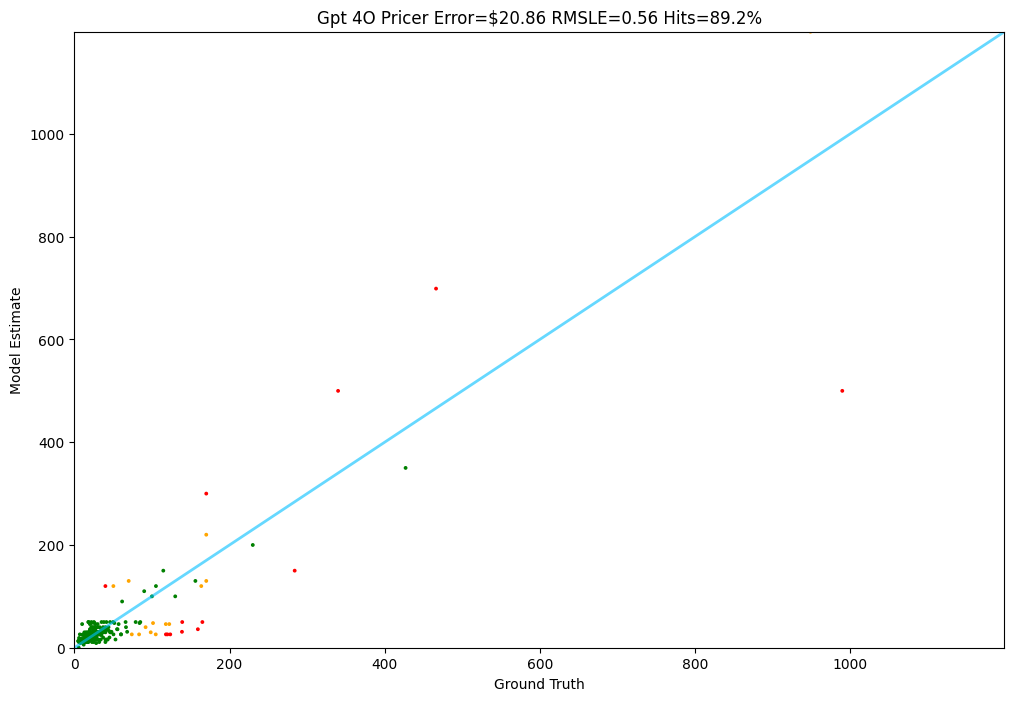

In [29]:
Tester.test(gpt_4o_pricer, test)

In [30]:
def claude_3_point_5_sonnet(item):
    messages = messages_for(item)
    system_message = messages[0]['content']
    messages = messages[1:]
    response = claude.messages.create(
        model="claude-3-5-sonnet-20240620",
        max_tokens=5,
        system=system_message,
        messages=messages
    )
    reply = response.content[0].text
    return get_price(reply)

1: Guess: $49.99 Truth: $65.99 Error: $16.00 SLE: 0.07 Item: Setpower Insulated Protective Cover for ...
2: Guess: $9.99 Truth: $9.68 Error: $0.31 SLE: 0.00 Item: TUAIC Refrigerator Door Light Switch 2 F...
3: Guess: $89.99 Truth: $155.98 Error: $65.99 SLE: 0.30 Item: Kegco Secondary Regulator, 3 Product, Ch...
4: Guess: $15.99 Truth: $5.59 Error: $10.40 SLE: 0.90 Item: MHY62044106 Refrigerator Door Spring 2Pc...
5: Guess: $30.99 Truth: $98.40 Error: $67.41 SLE: 1.29 Item: Ice-O-Matic 9131111-01 Float Valve
6: Guess: $42.99 Truth: $54.99 Error: $12.00 SLE: 0.06 Item: Wireless Temperature & Humidity Bluetoot...
7: Guess: $8.99 Truth: $5.71 Error: $3.28 SLE: 0.16 Item: 3Inch Thermometer Hygrometer for Indoor ...
8: Guess: $5.99 Truth: $9.53 Error: $3.54 SLE: 0.17 Item: GE WH1X2754 GE Timer Knob Assembly,white
9: Guess: $10.99 Truth: $11.24 Error: $0.25 SLE: 0.00 Item: newlifeapp 33001003 Dryer Lint Screen Fi...
10: Guess: $19.99 Truth: $12.88 Error: $7.11 SLE: 0.17 Item: Away NV350 NV351

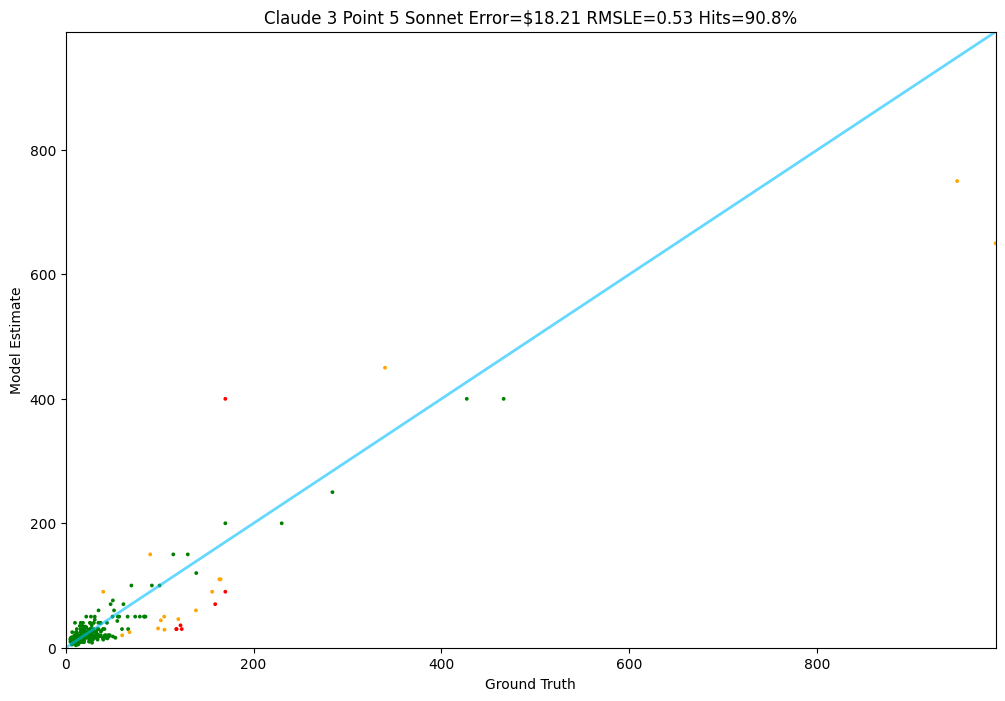

In [31]:
Tester.test(claude_3_point_5_sonnet, test)